In [90]:
import seaborn as sns
import pandas as pd
from pyspark.sql import Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RetailRocket")
    .getOrCreate()
)

In [21]:
df_events = spark.read.csv(
    "../data/interim/events.csv",
    header=True,
    inferSchema=True
)

df_prop_1 = spark.read.csv(
    "../data/interim/item_properties_part1.csv",
    header=True,
    inferSchema=True
)

df_prop_2 = spark.read.csv(
    "../data/interim/item_properties_part2.csv",
    header=True,
    inferSchema=True
)
df_prop = df_prop_1.unionByName(df_prop_2)

In [23]:
window_spec = (
    Window
    .partitionBy("itemid", "property")
    .orderBy(F.col("timestamp").desc())
)

df_prop_last = (
    df_prop
    .withColumn("rn", F.row_number().over(window_spec))
    .filter(F.col("rn") == 1)
    .drop("rn")
)

df_items = (
    df_prop_last
    .filter(F.col("property").isin(["categoryid", "available"]))
    .groupBy("itemid")
    .pivot("property")
    .agg(F.first("value"))
)

df_eda = df_events.join(df_items, on="itemid", how="left")

# Baseline 1 - popularity

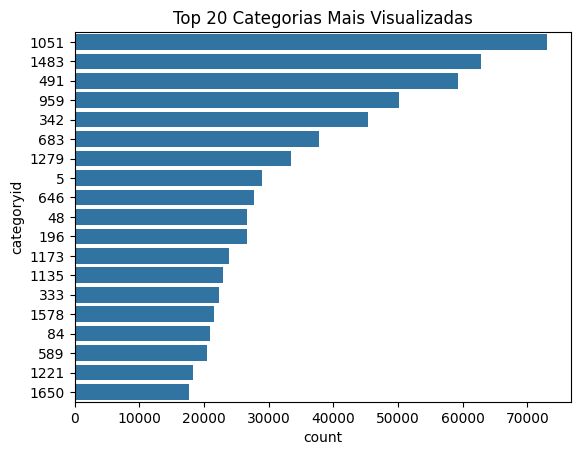

In [24]:
# Baseline 1 - popularity
views_categoria = (
    df_eda
    .filter("event='view'")
    .groupBy("categoryid")
    .count()
    .orderBy("count", ascending=False)
    .limit(20)
    .toPandas()
)

sns.barplot(
    data=views_categoria,
    y="categoryid",
    x="count"
)

plt.title("Top 20 Categorias Mais Visualizadas")
plt.show()

In [96]:
popularity = (
    df_treino_spark
    .groupBy("itemid")
    .agg(
        F.sum(
            F.when(F.col("event") == "view", 1)
             .when(F.col("event") == "addtocart", 3)
             .when(F.col("event") == "transaction", 5)
             .otherwise(0)
        ).alias("score")
    )
    .orderBy("score", ascending=False)
)

# Top N itens — será a recomendação para qualquer usuário
top_n_items = popularity.limit(10).toPandas()
print(top_n_items)

   itemid  score
0  461686   1019
1  119736    887
2  257040    686
3    9877    662
4  312728    549
5  241555    526
6  445351    500
7  309778    495
8   29196    485
9  369447    466


C:\Python311\Lib\socket.py:777: ResourceWarning: unclosed <socket.socket fd=3900, family=2, type=1, proto=0, laddr=('127.0.0.1', 59391), raddr=('127.0.0.1', 59390)>
  self._sock = None


In [97]:
gt_dict = dict(
    zip(
        gt_pd["visitorid"],
        gt_pd["itens_relevantes"]
    )
)

In [98]:
precisoes = []
recalls = []
ndcgs = []
todas_recs = []

for visitor_id, relevantes in gt_dict.items():

    relevantes = set(relevantes)

    if len(relevantes) == 0:
        continue

    recs = top_n_items

    todas_recs.append(recs)

    precisoes.append(
        precision_at_k(
            recs,
            relevantes,
            10
        )
    )

    recalls.append(
        recall_at_k(
            recs,
            relevantes,
            10
        )
    )

    ndcgs.append(
        ndcg_at_k(
            recs,
            relevantes,
            10
        )
    )

In [99]:
metricas_pop = {
    "precision_at_10": np.mean(precisoes),
    "recall_at_10": np.mean(recalls),
    "ndcg_at_10": np.mean(ndcgs),
    "coverage": coverage(
        todas_recs,
        len(unique_items)
    )
}

In [100]:
print("\n── Popularidade ──────────────────")

for nome, valor in metricas_pop.items():
    print(f"{nome:<20} {valor:.4f}")


── Popularidade ──────────────────
precision_at_10      0.0000
recall_at_10         0.0000
ndcg_at_10           0.0000
coverage             0.0001


# Baseline 2 - Modelo de KNN

In [26]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession, Window
import pyspark.sql.functions as F

from scipy.sparse import csr_matrix, save_npz
from sklearn.neighbors import NearestNeighbors

In [ ]:
SparkSession.builder \
    .appName("recomendacao") \
    .getOrCreate()

In [56]:
spark.conf.set("spark.sql.shuffle.partitions","48")

In [36]:
WEIGHTS = {"view": 1, "addtocart": 3, "transaction": 5}

interacoes = (
    df_eda
    .withColumn(
        "peso",
        F.when(F.col("event") == "view", F.lit(1))
         .when(F.col("event") == "addtocart", F.lit(3))
         .when(F.col("event") == "transaction", F.lit(5))
         .otherwise(F.lit(0)),
    )
    .groupBy("visitorid", "itemid")
    .agg(F.sum("peso").alias("peso"))
)

interacoes.show(10)

+---------+------+----+
|visitorid|itemid|peso|
+---------+------+----+
|   623748|305760|   1|
|   820159|281211|   1|
|  1312385|337358|   1|
|  1154250|367790|   6|
|   260791|323381|   1|
|   302896|257196|   2|
|   649450| 19664|   1|
|   322407|277275|   4|
|  1305172|446534|   1|
|  1293117|405481|   1|
+---------+------+----+
only showing top 10 rows



In [58]:
# Contar interações por usuário
contagem_usuarios = (
    interacoes
    .groupBy("visitorid")
    .agg(F.count("itemid").alias("n_itens"))
)

# Manter só usuários com >= 5 itens distintos
usuarios_ativos = (
    contagem_usuarios
    .filter(F.col("n_itens") >= 5)
    .select("visitorid")
)

usuarios_ativos = (
    usuarios_ativos
    .cache()
)

usuarios_ativos.count()

interacoes_filtradas = interacoes.join(usuarios_ativos, on="visitorid", how="inner")

total_usuarios = interacoes.select("visitorid").distinct().count()
usuarios_mantidos = usuarios_ativos.count()

print(f"Usuários totais:   {total_usuarios:>8,}")
print(f"Usuários ativos:   {usuarios_mantidos:>8,}")
print(f"Descartados:       {total_usuarios - usuarios_mantidos:>8,} "
      f"({(1 - usuarios_mantidos/total_usuarios)*100:.1f}%)")

Usuários totais:   1,407,580
Usuários ativos:     39,635
Descartados:       1,367,945 (97.2%)


In [63]:
from pyspark.sql import functions as F
from pyspark import StorageLevel

# =====================================================
# Preparação dos eventos
# =====================================================

df_com_ts = (
    df_events
    .withColumn(
        "peso",
        F.when(F.col("event") == "view", 1)
         .when(F.col("event") == "addtocart", 3)
         .when(F.col("event") == "transaction", 5)
         .otherwise(0)
    )
    .join(usuarios_ativos, "visitorid")
)

# Persistir para evitar recomputações
df_com_ts = df_com_ts.persist(StorageLevel.MEMORY_AND_DISK)
df_com_ts.count()

# =====================================================
# Split temporal (80% treino / 20% teste)
# =====================================================

cutoff = df_com_ts.approxQuantile(
    "timestamp",
    [0.8],
    0.01
)[0]

df_treino_spark = (
    df_com_ts
    .filter(F.col("timestamp") <= cutoff)
)

df_teste_spark = (
    df_com_ts
    .filter(F.col("timestamp") > cutoff)
)

print(f"Eventos treino: {df_treino_spark.count():,}")
print(f"Eventos teste:  {df_teste_spark.count():,}")

# =====================================================
# Interações treino
# =====================================================

interacoes_treino = (
    df_treino_spark
    .groupBy("visitorid", "itemid")
    .agg(F.sum("peso").alias("peso"))
    .persist(StorageLevel.MEMORY_AND_DISK)
)

interacoes_treino.count()

# =====================================================
# Ground truth
# =====================================================

ground_truth = (
    df_teste_spark
    .groupBy("visitorid")
    .agg(
        F.collect_set("itemid")
         .alias("itens_relevantes")
    )
)

# =====================================================
# AMOSTRAGEM PARA MLP
# =====================================================

usuarios_sample = (
    interacoes_treino
    .select("visitorid")
    .distinct()
    .sample(False, 0.10, seed=42)
)

interacoes_sample = (
    interacoes_treino
    .join(usuarios_sample, "visitorid")
)

ground_truth_sample = (
    ground_truth
    .join(usuarios_sample, "visitorid")
)

print("Interações amostra:",
      interacoes_sample.count())

# =====================================================
# Converter apenas a amostra para Pandas
# =====================================================

df_pd = interacoes_sample.toPandas()
gt_pd = ground_truth_sample.toPandas()

Eventos treino: 523,524
Eventos teste:  132,305
Interações amostra: 35786


In [73]:
import numpy as np
from scipy.sparse import csr_matrix

unique_users = df_pd["visitorid"].unique()
unique_items = df_pd["itemid"].unique()

user_to_idx = {
    user: idx
    for idx, user in enumerate(unique_users)
}

item_to_idx = {
    item: idx
    for idx, item in enumerate(unique_items)
}

idx_to_user = {
    idx: user
    for user, idx in user_to_idx.items()
}

idx_to_item = {
    idx: item
    for item, idx in item_to_idx.items()
}

rows = df_pd["visitorid"].map(user_to_idx)
cols = df_pd["itemid"].map(item_to_idx)
data = df_pd["peso"].astype(np.float32)

matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(
        len(unique_users),
        len(unique_items)
    )
)

print(f"Matriz: {matrix.shape}")
print(
    f"Densidade: "
    f"{100 * matrix.nnz / (matrix.shape[0] * matrix.shape[1]):.6f}%"
)
print(
    f"Memória sparse: "
    f"{matrix.data.nbytes / 1024**2:.2f} MB"
)

Matriz: (3356, 22133)
Densidade: 0.048178%
Memória sparse: 0.14 MB


In [74]:
K_NEIGHBORS = 20
N_RECS = 10

knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute",   # único compatível com cosine + sparse
    n_neighbors=K_NEIGHBORS + 1,  # +1 porque o próprio usuário aparece
    n_jobs=-1,           # usa todos os cores disponíveis
)

knn.fit(matrix)
print("KNN treinado.")

KNN treinado.


In [75]:
def recomendar_knn(
    user_idx: int,
    matrix: csr_matrix,
    knn_model: NearestNeighbors,
    idx_to_item: dict,
    n: int = 10,
):
    
    """Retorna os n itens recomendados para um usuário pelo índice."""
    distances, neighbors = knn_model.kneighbors(matrix[user_idx])

    # Remove o próprio usuário (sempre distância 0, sempre posição 0)
    neighbor_idxs  = neighbors[0][1:]
    similarities   = 1 - distances[0][1:]   # cosseno: distância → similaridade

    # Soma ponderada: cada vizinho contribui com seus itens × sua similaridade
    neighbor_matrix = matrix[neighbor_idxs]

    scores = similarities @ neighbor_matrix
    scores = np.asarray(scores).ravel()

    # Zerar itens que o usuário já viu
    ja_viu = matrix[user_idx].nonzero()[1]
    scores[ja_viu] = -np.inf

    top_idxs = np.argsort(scores)[::-1][:n]
    return [idx_to_item[i] for i in top_idxs]


In [76]:
def precision_at_k(recomendados: list, relevantes: set, k: int) -> float:
    hits = len(set(recomendados[:k]) & relevantes)
    return hits / k

def recall_at_k(recomendados: list, relevantes: set, k: int) -> float:
    if not relevantes:
        return 0.0
    hits = len(set(recomendados[:k]) & relevantes)
    return hits / len(relevantes)

def ndcg_at_k(recomendados: list, relevantes: set, k: int) -> float:
    dcg = sum(
        1 / np.log2(rank + 2)
        for rank, item in enumerate(recomendados[:k])
        if item in relevantes
    )
    ideal = sum(1 / np.log2(i + 2) for i in range(min(len(relevantes), k)))
    return dcg / ideal if ideal > 0 else 0.0

def coverage(todas_recs: list[list], n_itens_total: int) -> float:
    unicos = {item for recs in todas_recs for item in recs}
    return len(unicos) / n_itens_total

In [77]:
SEED = 42
N_SAMPLE = 3_000  # amostra para não travar o notebook

# Usuários que existem tanto no treino quanto no ground truth
gt_dict = dict(zip(gt_pd["visitorid"], gt_pd["itens_relevantes"]))
usuarios_teste = [
    u for u in gt_dict
    if u in user_to_idx  # só quem está na matriz de treino
]

rng = np.random.default_rng(SEED)
amostra = rng.choice(
    usuarios_teste,
    size=min(N_SAMPLE, len(usuarios_teste)),
    replace=False
)

precisoes, recalls, ndcgs, todas_recs = [], [], [], []

for visitor_id in amostra:
    u_idx = user_to_idx[visitor_id]
    relevantes = set(gt_dict[visitor_id])

    if not relevantes:
        continue

    recs = recomendar_knn(u_idx, matrix, knn, idx_to_item, n=N_RECS)
    todas_recs.append(recs)

    precisoes.append(precision_at_k(recs, relevantes, N_RECS))
    recalls.append(recall_at_k(recs, relevantes, N_RECS))
    ndcgs.append(ndcg_at_k(recs, relevantes, N_RECS))

metricas_knn = {
    "precision_at_10": np.mean(precisoes),
    "recall_at_10":    np.mean(recalls),
    "ndcg_at_10":      np.mean(ndcgs),
    "coverage":        coverage(todas_recs, len(unique_items)),
}

print("\n── KNN User-CF ──────────────────")
for k, v in metricas_knn.items():
    print(f"  {k:<20} {v:.4f}")


── KNN User-CF ──────────────────
  precision_at_10      0.0028
  recall_at_10         0.0078
  ndcg_at_10           0.0056
  coverage             0.1261


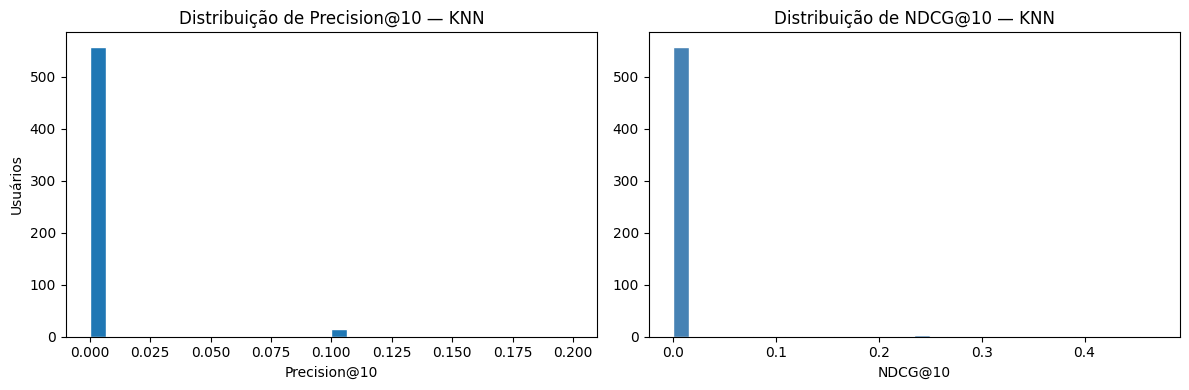


Usuários com pelo menos 1 hit: 15 / 573 (2.6%)


In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição de precision por usuário
axes[0].hist(precisoes, bins=30, edgecolor="white")
axes[0].set_title("Distribuição de Precision@10 — KNN")
axes[0].set_xlabel("Precision@10")
axes[0].set_ylabel("Usuários")

# Distribuição de NDCG por usuário
axes[1].hist(ndcgs, bins=30, edgecolor="white", color="steelblue")
axes[1].set_title("Distribuição de NDCG@10 — KNN")
axes[1].set_xlabel("NDCG@10")

plt.tight_layout()
plt.show()

print(f"\nUsuários com pelo menos 1 hit: "
      f"{sum(p > 0 for p in precisoes)} / {len(precisoes)} "
      f"({sum(p > 0 for p in precisoes)/len(precisoes)*100:.1f}%)")

In [80]:
Path("../data/features").mkdir(parents=True, exist_ok=True)

save_npz("../data/features/user_item_matrix.npz", matrix)

with open("../data/features/mappings.pkl", "wb") as f:
    pickle.dump({
        "user_to_idx": user_to_idx,
        "item_to_idx": item_to_idx,
        "idx_to_item": idx_to_item,
        "idx_to_user": idx_to_user,
    }, f)

# Salvar ground truth para reusar na avaliação do SVD e MLP
gt_pd.to_parquet("../data/features/ground_truth.parquet", index=False)

print("Arquivos salvos em data/features/")
print(f"  user_item_matrix.npz  {matrix.data.nbytes / 1e6:.1f} MB")
print(f"  mappings.pkl")
print(f"  ground_truth.parquet  {len(gt_pd):,} usuários")

Arquivos salvos em data/features/
  user_item_matrix.npz  0.1 MB
  mappings.pkl
  ground_truth.parquet  573 usuários


# Baseline 3 - SVD

In [83]:
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import load_npz

# Reutiliza exatamente a mesma matriz e ground truth do KNN
# Nenhuma linha de PySpark necessária a partir daqui

svd = TruncatedSVD(n_components=50, random_state=SEED)
user_factors = svd.fit_transform(matrix)   # (n_users, 50)
item_factors = svd.components_.T           # (n_items, 50)

def recomendar_svd(
    user_idx: int,
    n: int = N_RECS
):
    scores = user_factors[user_idx] @ item_factors.T

    itens_vistos = matrix[user_idx].indices
    scores[itens_vistos] = -np.inf

    top_idxs = np.argpartition(
        scores,
        -n
    )[-n:]

    top_idxs = top_idxs[
        np.argsort(scores[top_idxs])[::-1]
    ]

    return [
        idx_to_item[i]
        for i in top_idxs
    ]

In [84]:
precisoes = []
recalls = []
ndcgs = []
todas_recs = []

for visitor_id in amostra:

    u_idx = user_to_idx[visitor_id]

    relevantes = set(
        gt_dict[visitor_id]
    )

    if not relevantes:
        continue

    recs = recomendar_svd(
        u_idx,
        n=N_RECS
    )

    todas_recs.append(recs)

    precisoes.append(
        precision_at_k(
            recs,
            relevantes,
            N_RECS
        )
    )

    recalls.append(
        recall_at_k(
            recs,
            relevantes,
            N_RECS
        )
    )

    ndcgs.append(
        ndcg_at_k(
            recs,
            relevantes,
            N_RECS
        )
    )


metricas_svd = {
    "precision@10": np.mean(precisoes),
    "recall@10": np.mean(recalls),
    "ndcg@10": np.mean(ndcgs),
    "coverage": coverage(
        todas_recs,
        len(unique_items)
    ),
    "usuarios_avaliados": len(precisoes),
}

In [85]:
print("\n── SVD ──────────────────")

for nome, valor in metricas_svd.items():
    print(
        f"{nome:<20} {valor:.4f}"
    )


── SVD ──────────────────
precision@10         0.0002
recall@10            0.0002
ndcg@10              0.0003
coverage             0.0241
usuarios_avaliados   573.0000


# Tabela comparativa entre modelos

In [ ]:
comparacao = (
    pd.DataFrame([
        {"Modelo": "Popularidade", **metricas_pop},
        {"Modelo": "KNN User-CF", **metricas_knn},
        {"Modelo": "SVD", **metricas_svd},
        {"Modelo": "ALS", **metricas_als},
        {"Modelo": "MLP", **metricas_mlp},
    ])
    .round(4)
)

NameError: name 'metricas_pop' is not defined

In [88]:
import pandas as pd

comparacao = pd.DataFrame([
    {
        "Modelo": "Popularidade",
        **metricas_pop
    },
    {
        "Modelo": "KNN User-CF",
        **metricas_knn
    },
    {
        "Modelo": "SVD",
        **metricas_svd
    },
    {
        "Modelo": "ALS",
        **metricas_als
    },
    {
        "Modelo": "MLP",
        **metricas_mlp
    }
])

comparacao = comparacao.round(4)

comparacao

NameError: name 'metricas_pop' is not defined